## Montar Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/MyDrive/Meli_Case'

In [3]:
import sys
sys.path.append(path)

## Imports

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import ks_2samp
import shap
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler

## Funções

In [6]:
def plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val):

    fpr_test, tpr_test, _ = roc_curve(y_test, y_probs_test)
    roc_auc_test = roc_auc_score(y_test, y_probs_test)

    fpr_val, tpr_val, _ = roc_curve(y_val, y_probs_val)
    roc_auc_val = roc_auc_score(y_val, y_probs_val)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_test, tpr_test, label=f'Teste (AUC = {roc_auc_test:.2f})')
    plt.plot(fpr_val, tpr_val, label=f'Validação (AUC = {roc_auc_val:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()

In [7]:
def encontrar_threshold_max_lucro(y_true, y_prob, montos, best_threshold_f1, thresholds=np.linspace(0.01, 0.99, 100)):
    balanco = []
    lucros = []

    y_true = y_true.values

    for t in thresholds:
        y_pred = (y_prob > t).astype(int)

        balanco_total = np.sum([
            +0.25 * m if (yt == 0 and yp == 0) else   # Legítimas aprovadas
            -0.25 * m if (yt == 0 and yp == 1) else   # Legítimas bloqueadas
            -1.00 * m if (yt == 1 and yp == 0) else   # Fraudes aprovadas
            +1.00 * m if (yt == 1 and yp == 1) else 0 # Fraudes detectadas
            for yt, yp, m in zip(y_true, y_pred, montos)
        ])

        balanco.append(balanco_total)

        lucro_real = np.sum([
            +0.25 * m if (yt == 0 and yp == 0) else   # Legítimas aprovadas
            # -0.25 * m if (yt == 0 and yp == 1) else   # Legítimas bloqueadas
            -1.00 * m if (yt == 1 and yp == 0) else   0 # Fraudes aprovadas
            # +1.00 * m if (yt == 1 and yp == 1) else 0 # Fraudes detectadas
            for yt, yp, m in zip(y_true, y_pred, montos)
        ])

        lucros.append(lucro_real)

    melhor_threshold = thresholds[np.argmax(lucros)]
    lucro_maximo = max(lucros)

    print(f"Melhor Threshold para Lucro: {melhor_threshold:.2f}")
    print(f"Lucro Máximo: {lucro_maximo:.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, lucros)
    plt.xlabel("Threshold")
    plt.ylabel("Lucro Real")
    plt.title("Lucro vs Threshold")
    plt.axvline(melhor_threshold, color='red', linestyle='--', label=f"Melhor Threshold Lucro = {melhor_threshold:.2f}")
    plt.axvline(best_threshold_f1, color='blue', linestyle='--', label=f"Melhor Threshold  F1-SCORE = {best_threshold_f1:.2f}")
    plt.grid(True)
    plt.legend()
    plt.show()

    return melhor_threshold, lucro_maximo

In [8]:
def metricas_fraude(cm, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
    alert_rate = fp / (tp + fp) if (tp + fp) > 0 else 0
    hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
    rejection_rate = (tp + fp) / (tp + fp + tn + fn)  # fraudes + falsos alertas

    print("Métricas específicas de Fraude:")
    print(f"Detection Rate (Recall):     {detection_rate:.4f}")
    print(f"Alert Rate (False Alarm):    {alert_rate:.4f}")
    print(f"Hit Rate (Precision):        {hit_rate:.4f}")
    print(f"Rejection Rate (Alertas):    {rejection_rate:.4f}")

In [9]:
def analisar_metricas_por_decil(y_true, y_proba):
    df_score = pd.DataFrame({
        'y_true': y_true,
        'score': y_proba
    })

    df_score['decil'] = pd.qcut(df_score['score'], 10, labels=False, duplicates='drop')

    total_fraudes = df_score['y_true'].sum()
    total_transacoes = len(df_score)

    resultados = []

    for decil in range(9, -1, -1):
        grupo = df_score[df_score['decil'] == decil]
        tp = grupo['y_true'].sum()
        fp = len(grupo) - tp
        alertas = len(grupo)

        hit_rate = tp / alertas if alertas > 0 else 0
        detection_rate = tp / total_fraudes if total_fraudes > 0 else 0
        alert_rate = alertas / total_transacoes

        score_min = grupo['score'].min()*1000
        score_max = grupo['score'].max()*1000

        resultados.append({
            'Decil': f'{decil + 1}',
            'Score Mínimo': round(score_min),
            'Score Máximo': round(score_max),
            'Transações': alertas,
            'Fraudes': int(tp),
            'Hit Rate': round(hit_rate, 4),
            'Detection Rate': round(detection_rate, 4),
            'Alert Rate': round(alert_rate, 4),
        })

    return pd.DataFrame(resultados)


In [10]:
def calculate_profit(y_true, y_pred, amounts):
    amounts = amounts.loc[y_true.index]
    tp = np.sum((y_true == 1) & (y_pred == 1))  # Fraudes detectadas e bloqueadas (Somar e *(+1))
    fp = np.sum((y_true == 0) & (y_pred == 1))  # Transação Legítimas bloqueadas (Somar e *(-0,25))
    tn = np.sum((y_true == 0) & (y_pred == 0))  # Transação Legítimas Aprovadas (Somar e *0,25)
    fn = np.sum((y_true == 1) & (y_pred == 0))  # Fraudes Aprovada (Somar e *(-1))


    Lucro_Bruto = 0.25 * np.sum(amounts[(y_true == 0) & (y_pred == 0)])
    Save = np.sum(amounts[(y_true == 1) & (y_pred == 1)])
    Saldo_Neg = -0.25 * np.sum(amounts[(y_true == 0) & (y_pred == 1)])
    Prejuizo = -1.00 * np.sum(amounts[(y_true == 1) & (y_pred == 0)])

    print(f"Lucro: {Lucro_Bruto:.2f}") #Quanto ganhei
    print(f"Prejuizo: {Prejuizo:.2f}") # Quanto perdi por Fraude
    print(f"Save : {Save:.2f}") # Quanto salvei
    print(f"Saldo Negativo: {Saldo_Neg:.2f}") #Quanto deixei de ganhar
    print(f"Balanço Total: {Lucro_Bruto + Prejuizo + Save + Saldo_Neg:.2f}")
    print(f"Lucro Real: {Lucro_Bruto + Prejuizo:.2f}")
    return

## Base

In [11]:
base = pd.read_excel(f"{path}/fraud_dataset.xlsx")
base = base.rename(columns={col: f"var_{col}" for col in base.columns if len(col) == 1 and col.isalpha()})

In [12]:
variaveis = ["var_Q", "var_R", "var_S", 'Monto']

for col in variaveis:
    base[col] = base[col].apply(lambda x: np.nan if isinstance(x, datetime) else x)

    base[col] = base[col].astype(str).str.replace(",", "").str.replace(" ", "").replace("None", np.nan)
    base[col] = pd.to_numeric(base[col], errors='coerce')

In [13]:
for col in ["var_C", "var_F", "var_G"]:
    base[f"{col}_log"] = np.log1p(base[col])

In [14]:
def mapear_pais(pais):
    if pais in ['BR', 'AR', 'MX']:
        return pais
    elif pais in ['ES', 'US', 'UY']:
        return 'ES_US_UY'
    else:
        return 'OUTROS'

base['pais_agg'] = base['var_J'].apply(mapear_pais)

In [15]:
pais_agg_dummies = pd.get_dummies(base['pais_agg'], prefix='pais_agg')
pais_agg_dummies = pais_agg_dummies.astype(int)

In [16]:
base = pd.concat([base, pais_agg_dummies], axis=1)
base

,var_A,var_B,var_C,var_D,var_E,var_F,var_G,var_H,var_I,var_J,...,Fraude,var_C_log,var_F_log,var_G_log,pais_agg,pais_agg_AR,pais_agg_BR,pais_agg_ES_US_UY,pais_agg_MX,pais_agg_OUTROS
0,0,10,50257.0,0,0,0.0,0.0,0,0,UY,...,1,10.824925,0.000000,0.0,ES_US_UY,0,0,1,0,0
1,0,10,29014.0,0,0,0.0,0.0,0,0,UY,...,1,10.275568,0.000000,0.0,ES_US_UY,0,0,1,0,0
2,0,7,92.0,0,1,0.0,0.0,0,1,UY,...,1,4.532599,0.000000,0.0,ES_US_UY,0,0,1,0,0
3,9,16,50269.0,0,0,0.0,0.0,0,0,UY,...,1,10.825164,0.000000,0.0,ES_US_UY,0,0,1,0,0
4,0,8,8180.0,0,0,0.0,0.0,0,0,UY,...,1,9.009570,0.000000,0.0,ES_US_UY,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16875,0,3,63302.0,0,1,0.5,0.0,0,0,BR,...,1,11.055688,0.405465,0.0,BR,0,1,0,0,0
16876,0,12,825.0,0,0,0.0,0.0,0,0,BR,...,1,6.716595,0.000000,0.0,BR,0,1,0,0,0
16877,1,3,81067.0,0,0,0.0,0.0,0,0,BR,...,1,11.303044,0.000000,0.0,BR,0,1,0,0,0
16878,0,9,398372.0,0,0,0.0,0.0,0,0,BR,...,1,12.895144,0.000000,0.0,BR,0,1,0,0,0


In [17]:
base['var_K_100'] = (base['var_K'] * 100).round()

In [18]:
drop_col = ['var_C', 'var_F', 'var_G', 'var_J', 'pais_agg', 'var_K']
base = base.drop(columns=drop_col, errors='ignore')
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16880 entries, 0 to 16879
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   var_A              16880 non-null  int64  
 1   var_B              16880 non-null  int64  
 2   var_D              16880 non-null  int64  
 3   var_E              16880 non-null  int64  
 4   var_H              16880 non-null  int64  
 5   var_I              16880 non-null  int64  
 6   var_L              16880 non-null  int64  
 7   var_M              16880 non-null  int64  
 8   var_N              16880 non-null  int64  
 9   var_O              16880 non-null  int64  
 10  var_P              16880 non-null  int64  
 11  var_Q              16863 non-null  float64
 12  var_R              16877 non-null  float64
 13  var_S              15575 non-null  float64
 14  Monto              16413 non-null  float64
 15  Fraude             16880 non-null  int64  
 16  var_C_log          136

In [19]:
df = base[base['Monto'].notna()]

## Treino, Teste e Validação

In [20]:
rf_fs = ['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'pais_agg_ES_US_UY',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'pais_agg_MX',
 'var_F_log',
 'pais_agg_AR',
 'pais_agg_BR',
 'var_Q',
 'var_D']

In [21]:
num_vars = ['var_S',
 'Monto',
 'var_C_log',
 'var_B',
 'var_K_100',
 'var_P',
 'var_M',
 'var_L',
 'var_A',
 'var_E',
 'var_F_log',
 'var_Q',
 'var_D']

cat_vars = ['pais_agg_ES_US_UY', 'pais_agg_MX', 'pais_agg_AR', 'pais_agg_BR']

In [22]:
X = df[rf_fs]
y = df["Fraude"]

In [23]:
X_num = X[num_vars].copy()
X_num.fillna(0, inplace=True)

X_cat = X[cat_vars].copy()
X_cat = X_cat.replace(0, -1)

In [24]:
X_num.shape, X_cat.shape

((16413, 13), (16413, 4))

In [25]:
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=X_num.columns)

In [26]:
X_num_scaled.shape

(16413, 13)

In [27]:
X_norm = pd.concat([X_num_scaled.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
X_norm

,var_S,Monto,var_C_log,var_B,var_K_100,var_P,var_M,var_L,var_A,var_E,var_F_log,var_Q,var_D,pais_agg_ES_US_UY,pais_agg_MX,pais_agg_AR,pais_agg_BR
0,-0.760734,-0.461045,0.982185,0.507984,2.127023,3.091448,1.432560,-0.651968,-0.288174,-0.280357,-0.293787,-0.113675,-0.096286,1,-1,-1,-1
1,-0.598342,-0.566418,0.846518,0.507984,-0.539603,1.256303,-0.531489,-0.651968,-0.288174,-0.280357,-0.293787,-0.113675,-0.096286,1,-1,-1,-1
2,2.174847,-0.545653,-0.571746,-0.133020,-0.539603,0.338730,1.432560,-0.651968,-0.288174,0.367833,-0.293787,-0.113675,-0.096286,1,-1,-1,-1
3,-0.935278,-0.259279,0.982244,1.789991,2.493684,3.091448,1.432560,-0.651968,8.014568,-0.280357,-0.293787,-0.113675,-0.096286,1,-1,-1,-1
4,-0.071764,-0.109356,0.533871,0.080648,-0.539603,-0.578843,-0.531489,-0.651968,-0.288174,-0.280357,-0.293787,-0.113675,-0.096286,1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16408,2.129186,-0.120961,1.039173,-0.987692,-0.539603,-0.578843,-0.531489,0.853061,-0.288174,0.367833,0.114224,-0.113675,-0.096286,-1,-1,-1,1
16409,-0.567410,-0.501175,-0.032394,0.935319,-0.539603,3.091448,-0.531489,0.853061,-0.288174,-0.280357,-0.293787,-0.113675,-0.096286,-1,-1,-1,1
16410,-0.138046,0.107031,1.100259,-0.987692,1.860361,-0.578843,-0.531489,-0.651968,0.634353,-0.280357,-0.293787,-0.113675,-0.096286,-1,-1,-1,1
16411,0.040180,-0.462985,1.493439,0.294316,-0.539603,-0.578843,0.450536,-0.651968,-0.288174,-0.280357,-0.293787,-0.113675,-0.096286,-1,-1,-1,1


In [28]:
X_norm.shape, X_num.shape, X_cat.shape

((16413, 17), (16413, 13), (16413, 4))

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(X_norm, y, test_size=0.4, stratify=y, random_state=13)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=13)

In [30]:
X_train.shape, X_test.shape, X_val.shape

((9847, 17), (3283, 17), (3283, 17))

## Optimização de Hiperparâmetros

In [31]:
from hyperopt import STATUS_OK
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from hyperopt import hp
from hyperopt import fmin, tpe, Trials
from sklearn.metrics import confusion_matrix, classification_report

In [32]:
def objective_logreg(params):
    """
    Otimiza uma Regressão Logística maximizando o F1-score.
    """
    model = LogisticRegression(
        penalty=params['penalty'],
        C=params['C'],
        solver=params['solver'],
        class_weight='balanced',  # importante para lidar com desbalanceamento
        max_iter=500,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)  # threshold padrão 0.5

    f1 = f1_score(y_test, y_pred)

    return {'loss': -f1, 'status': STATUS_OK}

In [33]:
space_logreg = {
    'C': hp.loguniform('C', np.log(1e-3), np.log(100)),
    'penalty': hp.choice('penalty', ['l2']),
    'solver': hp.choice('solver', ['liblinear', 'saga'])  # suportam regularização
}


In [34]:
trials_logreg = Trials()
best_logreg = fmin(
    fn=objective_logreg,
    space=space_logreg,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials_logreg,
    rstate=np.random.default_rng(42)
)

100%|██████████| 50/50 [00:41<00:00,  1.21trial/s, best loss: -0.579250720461095]


In [35]:
params_finais = {
    'C': best_logreg['C'],
    'penalty': 'l2',
    'solver': ['liblinear', 'saga'][best_logreg['solver']],
    'class_weight': 'balanced',
    'max_iter': 500,
    'random_state': 42
}

final_model = LogisticRegression(**params_finais)
final_model.fit(pd.concat([X_train, X_test]), pd.concat([y_train, y_test]))

LogisticRegression(C=np.float64(0.01151027195690431), class_weight='balanced',
                   max_iter=500, random_state=42, solver='saga')

In [36]:
y_probs_test = final_model.predict_proba(X_test)[:, 1]
y_probs_val = final_model.predict_proba(X_val)[:, 1]

## Avaliação do Modelo

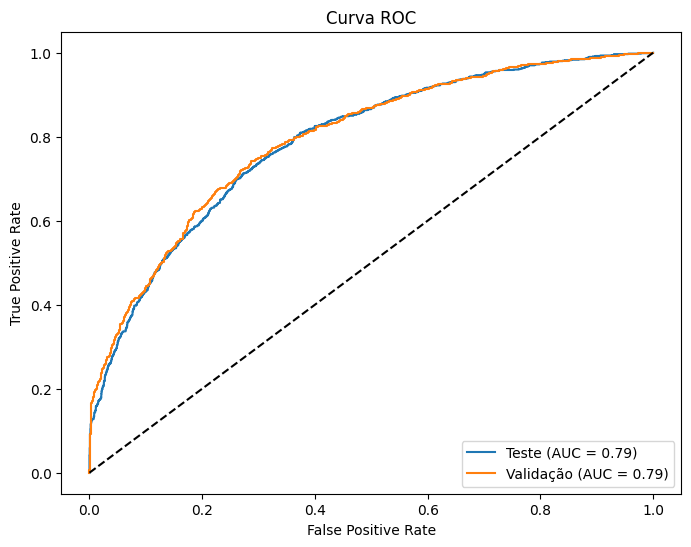

In [37]:
plot_roc_curves(y_test, y_probs_test, y_val, y_probs_val)

In [38]:
ks_test = ks_2samp(y_probs_test[y_test == 0], y_probs_test[y_test == 1]).statistic
ks_val = ks_2samp(y_probs_val[y_val == 0], y_probs_val[y_val == 1]).statistic

print(f"KS Test: {ks_test:.4f}")
print(f"KS Val: {ks_val:.4f}")

KS Test: 0.4403
KS Val: 0.4546


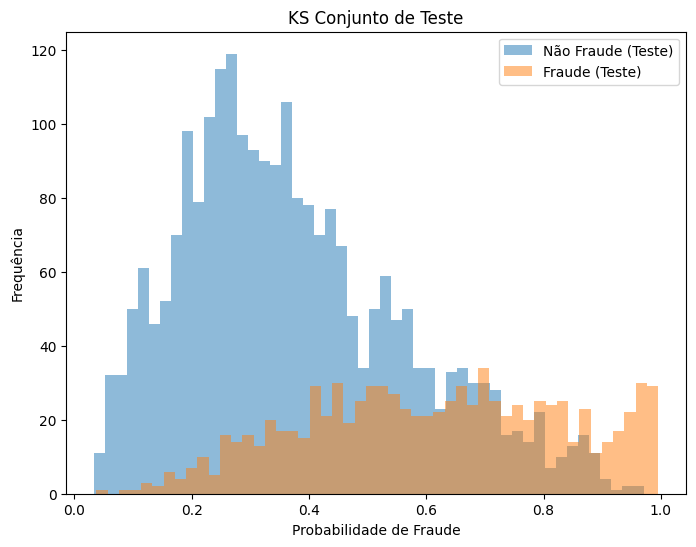

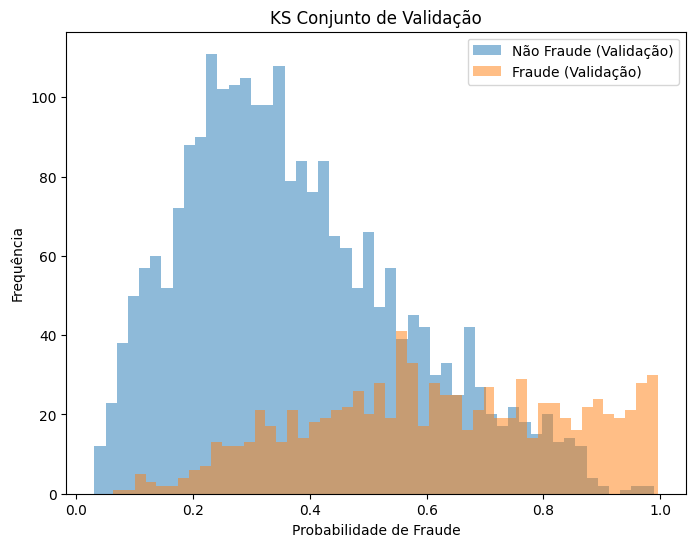

In [39]:
plt.figure(figsize=(8, 6))
plt.hist(y_probs_test[y_test == 0], bins=50, alpha=0.5, label='Não Fraude (Teste)')
plt.hist(y_probs_test[y_test == 1], bins=50, alpha=0.5, label='Fraude (Teste)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Teste')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y_probs_val[y_val == 0], bins=50, alpha=0.5, label='Não Fraude (Validação)')
plt.hist(y_probs_val[y_val == 1], bins=50, alpha=0.5, label='Fraude (Validação)')
plt.xlabel('Probabilidade de Fraude')
plt.ylabel('Frequência')
plt.title('KS Conjunto de Validação')
plt.legend()
plt.show()

In [40]:
ks_values = [ks_test, ks_val]
groups = ['Teste', 'Validação']

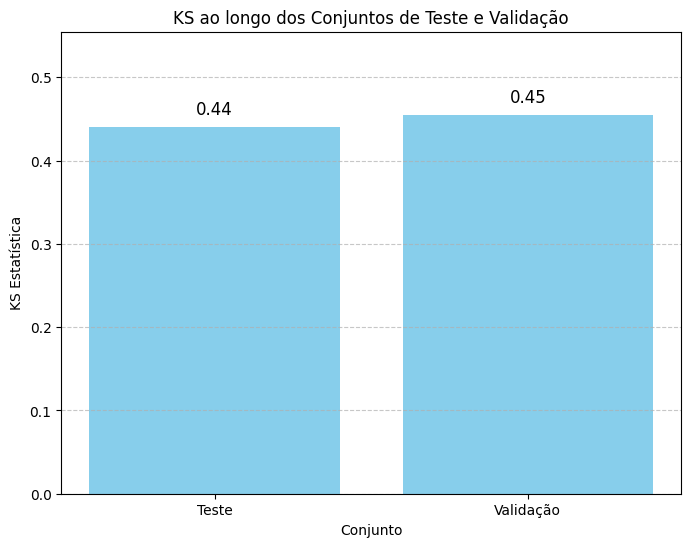

In [41]:
plt.figure(figsize=(8, 6))
bars = plt.bar(groups, ks_values, color='skyblue')
plt.xlabel("Conjunto")
plt.ylabel("KS Estatística")
plt.title("KS ao longo dos Conjuntos de Teste e Validação")
for bar, ks_val in zip(bars, ks_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{ks_val:.2f}",
             ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(ks_values) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [42]:
importance = final_model.coef_[0]

importance_df = pd.DataFrame({'Feature': rf_fs, 'Importance': importance})
importance_df.sort_values(by='Importance', ascending=True, inplace=True)
importance_df

,Feature,Importance
14,pais_agg_BR,-0.753969
16,var_D,-0.178421
15,var_Q,-0.088182
10,var_E,-0.085381
1,Monto,-0.028912
12,var_F_log,-0.006003
9,var_A,-0.001464
8,var_L,0.021008
7,var_M,0.047260
6,var_P,0.068186


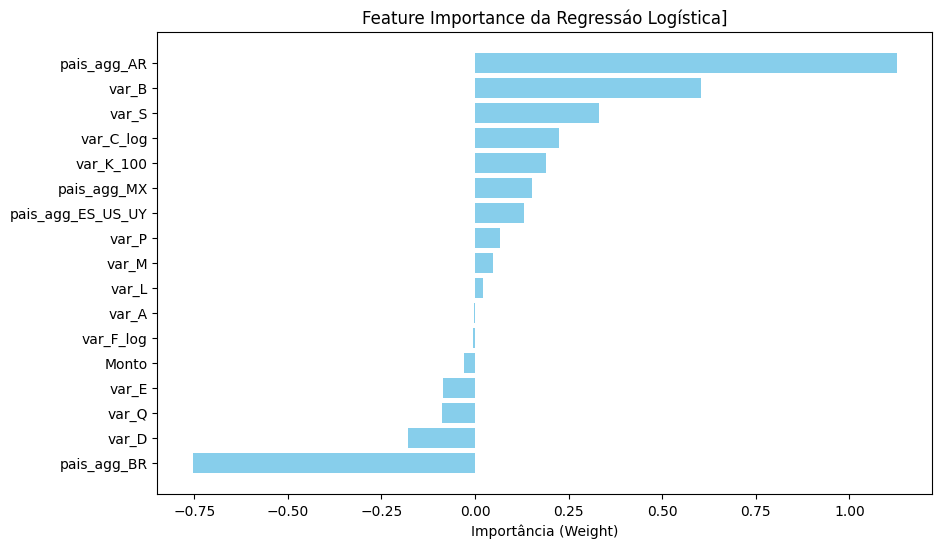

In [43]:
importance_df.sort_values(by='Importance', ascending=True, inplace=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Importância (Weight)")
plt.title("Feature Importance da Regressáo Logística]")
plt.show()

## Escolha do Threshold a partir do F1-SCORE

In [44]:
thresholds = np.linspace(0.01, 0.99, 100)

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (y_probs_test > t).astype(int)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

best_threshold_f1 = thresholds[np.argmax(f1_scores)].round(2)
print("Melhor threshold para F1-score:", best_threshold_f1)
print("F1-score correspondente:", np.max(f1_scores).round(4))

Melhor threshold para F1-score: 0.49
F1-score correspondente: 0.584


In [45]:
for i in range(len(thresholds)):
    print(f"Threshold: {thresholds[i]:.2f}, Precision: {precisions[i]:.4f}, Recall: {recalls[i]:.4f}, F1-Score: {f1_scores[i]:.4f}")

Threshold: 0.01, Precision: 0.2741, Recall: 1.0000, F1-Score: 0.4303
Threshold: 0.02, Precision: 0.2741, Recall: 1.0000, F1-Score: 0.4303
Threshold: 0.03, Precision: 0.2741, Recall: 1.0000, F1-Score: 0.4303
Threshold: 0.04, Precision: 0.2740, Recall: 0.9989, F1-Score: 0.4300
Threshold: 0.05, Precision: 0.2745, Recall: 0.9989, F1-Score: 0.4307
Threshold: 0.06, Precision: 0.2759, Recall: 0.9989, F1-Score: 0.4323
Threshold: 0.07, Precision: 0.2775, Recall: 0.9989, F1-Score: 0.4343
Threshold: 0.08, Precision: 0.2781, Recall: 0.9978, F1-Score: 0.4350
Threshold: 0.09, Precision: 0.2801, Recall: 0.9978, F1-Score: 0.4374
Threshold: 0.10, Precision: 0.2825, Recall: 0.9967, F1-Score: 0.4402
Threshold: 0.11, Precision: 0.2843, Recall: 0.9967, F1-Score: 0.4424
Threshold: 0.12, Precision: 0.2873, Recall: 0.9967, F1-Score: 0.4460
Threshold: 0.13, Precision: 0.2893, Recall: 0.9933, F1-Score: 0.4481
Threshold: 0.14, Precision: 0.2917, Recall: 0.9933, F1-Score: 0.4509
Threshold: 0.15, Precision: 0.2938

In [46]:
# best_threshold_f1 = 0.4
best_threshold_f1 = 0.5
best_threshold_f1

0.5

In [47]:
y_pred_test = (y_probs_test > best_threshold_f1).astype(int)
y_pred_val = (y_probs_val > best_threshold_f1).astype(int)

In [48]:
auc_test = roc_auc_score(y_test, y_probs_test)
f1_test = f1_score(y_test, y_pred_test)
auc_val = roc_auc_score(y_val, y_probs_val)
f1_val = f1_score(y_val, y_pred_val)

In [49]:
print("AUC (Teste):", auc_test)
print("F1-score (Teste):", f1_test)
print("AUC (validação):", auc_val)
print("F1-score (validação):", f1_val)

AUC (Teste): 0.788840863524036
F1-score (Teste): 0.5775451950523312
AUC (validação): 0.7945368082358474
F1-score (validação): 0.5876190476190476


In [50]:
metrics = {
    'Métrica': ['AUC', 'F1-Score'],
    'Teste': [auc_test, f1_test],
    'Validação': [auc_val, f1_val]
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Métrica,Teste,Validação
0,AUC,0.788841,0.794537
1,F1-Score,0.577545,0.587619


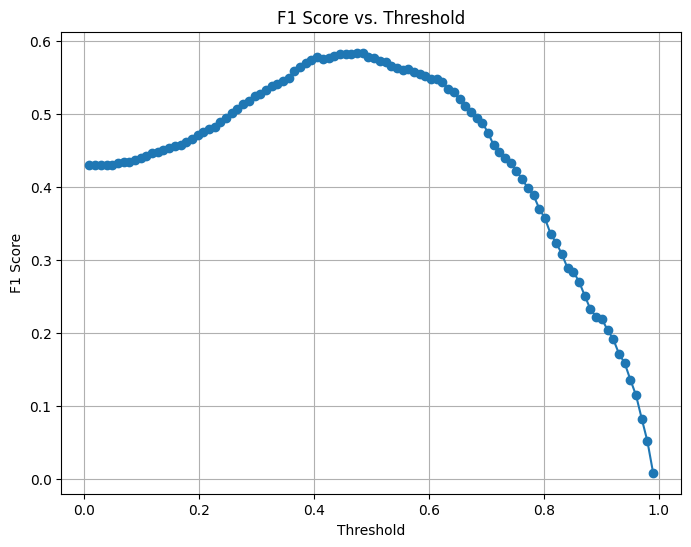

In [51]:
plt.figure(figsize=(8,6))
plt.plot(thresholds, f1_scores, marker='o')
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Threshold")
plt.grid(True)
plt.show()

## Avaliação do Modelo

In [52]:
cm = confusion_matrix(y_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

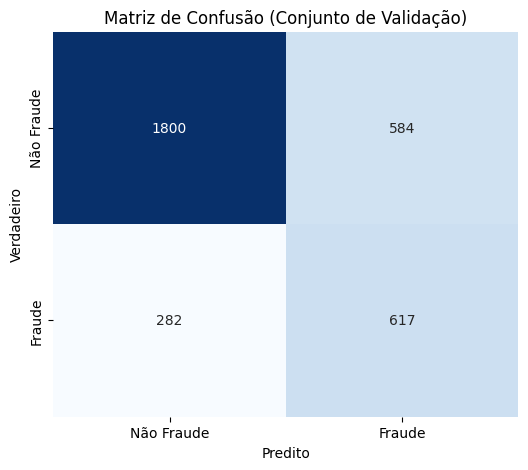

In [53]:
labels = ["Não Fraude", "Fraude"]
cm_matrix = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap="Blues", cbar=False)
plt.title('Matriz de Confusão (Conjunto de Validação)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

In [54]:
report = classification_report(y_val, y_pred_val, target_names=["Não Fraude", "Fraude"])
print("Classification Report (Validação):\n")
print(report)

Classification Report (Validação):

              precision    recall  f1-score   support

  Não Fraude       0.86      0.76      0.81      2384
      Fraude       0.51      0.69      0.59       899

    accuracy                           0.74      3283
   macro avg       0.69      0.72      0.70      3283
weighted avg       0.77      0.74      0.75      3283



## Salvar

In [ ]:
! jupyter nbconvert --to html 02_Modelagem_XGBoost.ipynb